# Projet NLP 2 -- Supervised Learning
## Analyse d'avis clients d'assurance (Insurance Reviews Analysis)
---
**Dataset** : 35 fichiers Excel contenant ~35 000 avis clients sur des assureurs francais.
Chaque avis contient une note (1-5), le texte de l'avis, le nom de l'assureur et le type de produit.

**Objectif** : Construire un pipeline NLP complet allant du nettoyage des donnees jusqu'a la mise en production d'une application interactive.

## Installations et Imports

In [1]:
# Installations
!pip install wordcloud plotly pyspellchecker tqdm -q
!pip install transformers sentencepiece sacremoses -q
!pip install gensim pyLDAvis bertopic -q
!pip install tensorflow -q
!pip install sentence-transformers scikit-learn xgboost shap -q
!pip install streamlit pyngrok -q
!python -m spacy download fr_core_news_sm -q
print("Installations terminées")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 82.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Installations terminées


In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('torch').setLevel(logging.ERROR)
logging.getLogger('gensim').setLevel(logging.ERROR)
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, pickle, io, warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk import ngrams
from wordcloud import WordCloud
import spacy

nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nlp = spacy.load('fr_core_news_sm')
print("Imports terminés")

Imports terminés


---
# A - Data Cleaning and Exploration

Dans cette partie, nous chargeons les 35 fichiers d'avis clients, nous explorons les donnees (missing values, distribution des notes, nombre de mots),
puis nous appliquons un pipeline de nettoyage : spelling correction, text cleaning (suppression URLs, chiffres, ponctuation),
tokenization et lemmatization avec spaCy. Enfin, nous analysons les frequent words, n-grams et wordclouds.

## A.1 - Data Loading

Chargement des 35 fichiers Excel et concatenation en un seul DataFrame.

In [6]:
dfs = []
for i in range(1, 36):
    try:
        df_tmp = pd.read_excel(f'avis_{i}_traduit.xlsx')
        df_tmp['source_fichier'] = f'avis_{i}'
        dfs.append(df_tmp)
        print(f" avis_{i} chargé : {df_tmp.shape}")
    except Exception as e:
        print(f" avis_{i} : {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nDataFrame final : {df.shape[0]} lignes, {df.shape[1]} colonnes")

 avis_1 chargé : (1000, 12)
 avis_2 chargé : (1000, 12)
 avis_3 chargé : (1000, 12)
 avis_4 chargé : (1000, 12)
 avis_5 chargé : (1000, 12)
 avis_6 chargé : (1000, 12)
 avis_7 chargé : (1000, 12)
 avis_8 chargé : (1000, 12)
 avis_9 chargé : (1000, 12)
 avis_10 chargé : (1000, 12)
 avis_11 chargé : (1000, 12)
 avis_12 chargé : (1000, 12)
 avis_13 chargé : (1000, 12)
 avis_14 chargé : (1000, 12)
 avis_15 chargé : (1000, 12)
 avis_16 chargé : (1000, 12)
 avis_17 chargé : (1000, 12)
 avis_18 chargé : (1000, 12)
 avis_19 chargé : (1000, 12)
 avis_20 chargé : (1000, 12)
 avis_21 chargé : (1000, 12)
 avis_22 chargé : (1000, 12)
 avis_23 chargé : (1000, 12)
 avis_24 chargé : (1000, 12)
 avis_25 chargé : (1000, 12)
 avis_26 chargé : (1000, 12)
 avis_27 chargé : (1000, 12)
 avis_28 chargé : (1000, 12)
 avis_29 chargé : (1000, 12)
 avis_30 chargé : (1000, 12)
 avis_31 chargé : (1000, 12)
 avis_32 chargé : (1000, 12)
 avis_33 chargé : (1000, 12)
 avis_34 chargé : (1000, 12)
 avis_35 chargé : (435,

## A.2 - Exploratory Data Analysis

Analyse des valeurs manquantes, statistiques descriptives sur les notes,
et detection/suppression des duplicate reviews.

In [7]:
print("Apercu du dataset")
display(df.head(5))

print("\nMissing values")
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({'Manquants': missing, '%': pct})[missing > 0])

print("\nStatistiques des notes")
print(df['note'].describe())

# Detection et suppression des duplicates
nb_doublons = df.duplicated(subset=['avis', 'assureur', 'note']).sum()
print(f"\nDuplicates détectés : {nb_doublons}")
df = df.drop_duplicates(subset=['avis', 'assureur', 'note']).reset_index(drop=True)
print(f"Après suppression : {df.shape[0]} lignes")

Apercu du dataset


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_fichier
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN,avis_1
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN,avis_1
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN,avis_1
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN,avis_1
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN,avis_1



Missing values


,Manquants,%
note,10331,30.00
auteur,1,0.00
avis_en,2,0.01
avis_cor,34000,98.74
avis_cor_en,34004,98.75



Statistiques des notes
count    24104.000000
mean         2.847619
std          1.531390
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: note, dtype: float64

Duplicates détectés : 20
Après suppression : 34415 lignes


## A.3 - Data Visualization (Plotly)

Visualisation interactive de la distribution des notes et de la note moyenne par assureur.

In [8]:
# Distribution des notes
fig1 = px.histogram(df, x='note', color='note', title='Distribution des notes',
                    color_discrete_sequence=px.colors.sequential.Blues_r,
                    category_orders={'note': [1, 2, 3, 4, 5]})
fig1.update_layout(bargap=0.1, showlegend=False, xaxis_title='Note', yaxis_title='Nombre')
fig1.show()

# Note moyenne par assureur
note_par_assureur = df.groupby('assureur')['note'].mean().sort_values().reset_index()
note_par_assureur.columns = ['assureur', 'note_moyenne']
moy_globale = df['note'].mean()

fig2 = px.bar(note_par_assureur, x='note_moyenne', y='assureur', orientation='h',
              title='Note moyenne par assureur',
              color='note_moyenne', color_continuous_scale='RdYlGn', range_color=[1, 5])
fig2.add_vline(x=moy_globale, line_dash="dash", line_color="red",
               annotation_text=f"Moy: {moy_globale:.2f}")
fig2.update_layout(yaxis_title='', xaxis_title='Note moyenne', height=600)
fig2.show()

## A.4 - Word Count Analysis

Analyse du nombre de mots par avis en fonction de la note. On observe generalement que les avis negatifs sont plus longs (les clients mecontents s'expriment davantage).

In [9]:
df['nb_mots'] = df['avis'].astype(str).apply(lambda x: len(x.split()))

fig = px.box(df, x='note', y='nb_mots', color='note',
             title='Nombre de mots par note',
             color_discrete_sequence=px.colors.sequential.Blues)
fig.update_layout(showlegend=False, xaxis_title='Note', yaxis_title='Nombre de mots')
fig.show()

print(f"Moyenne : {df['nb_mots'].mean():.1f} mots | Médiane : {df['nb_mots'].median():.0f} | Max : {df['nb_mots'].max()}")
df.to_csv('df_brut.csv', index=False, encoding='utf-8-sig')
print("df_brut.csv sauvegardé")

Moyenne : 58.6 mots | Médiane : 34 | Max : 1469
df_brut.csv sauvegardé


## A.5 - Spelling Correction and Text Cleaning

Application d'un spelling corrector (pyspellchecker) sur un echantillon de 2000 avis,
puis nettoyage du texte : mise en minuscules, suppression des URLs, chiffres et caracteres speciaux.
La correction est appliquee sur un sample car le traitement est couteux en temps.

In [10]:
from spellchecker import SpellChecker
from concurrent.futures import ProcessPoolExecutor
import multiprocessing

spell = SpellChecker(language='fr')
dico_connu = spell.word_frequency.words()
SAMPLE_SIZE = 2000

def corriger_texte_rapide(texte):
    if pd.isna(texte) or str(texte).strip() == "":
        return ""
    texte = str(texte)
    mots = texte.split()
    mots_corriges = []
    for mot in mots:
        mot_lower = mot.lower().strip()
        if len(mot_lower) < 3 or len(mot_lower) > 15 or not mot_lower.isalpha():
            mots_corriges.append(mot)
            continue
        if mot_lower in dico_connu:
            mots_corriges.append(mot)
            continue
        correction = spell.correction(mot_lower)
        if correction is not None:
            mots_corriges.append(correction)
        else:
            mots_corriges.append(mot)
    return ' '.join(mots_corriges)

sample_idx = df.sample(n=SAMPLE_SIZE, random_state=42).index
textes_sample = df.loc[sample_idx, 'avis'].tolist()

print(f"Spelling correction sur {SAMPLE_SIZE} avis...")
n_workers = multiprocessing.cpu_count()
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    resultats = list(executor.map(corriger_texte_rapide, textes_sample, chunksize=100))

df['avis_corrige'] = df['avis'].copy()
df.loc[sample_idx, 'avis_corrige'] = resultats

print("\n--- Exemples de corrections ---")
nb_ex = 0
for i in sample_idx:
    o = str(df['avis'].iloc[i])[:150]
    c = str(df['avis_corrige'].iloc[i])[:150]
    if o != c:
        print(f"AVANT  : {o}")
        print(f"APRÈS  : {c}\n")
        nb_ex += 1
        if nb_ex >= 5: break

nb_mod = sum(1 for o, c in zip(textes_sample, resultats) if str(o) != str(c))
print(f"Résultat : {nb_mod}/{SAMPLE_SIZE} avis corrigés ({nb_mod/SAMPLE_SIZE*100:.1f}%)")

# Text cleaning
def nettoyer_texte(texte):
    if pd.isna(texte) or texte == "":
        return ""
    texte = str(texte).lower()
    texte = re.sub(r'http\S+|www\S+', '', texte)
    texte = re.sub(r'\d+', '', texte)
    texte = re.sub(r'[^a-zàâçéèêëîïôûùüÿœæ\s]', ' ', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte

df['avis_clean'] = df['avis_corrige'].apply(nettoyer_texte)
print(f"\nText cleaning terminé sur {len(df)} avis.")

Spelling correction sur 2000 avis...

--- Exemples de corrections ---
AVANT  : Bonjour,
Mon mari est en ALD depuis le 7 avril 2020 nous avons envoyé les documents par le site et a ce jour tjs rien nous vivons a 5 avec 440 euros t
APRÈS  : Bonjour, mon mari est en and depuis le 7 avril 2020 nous avons envoyé les documents par le site et a ce jour tes rien nous vivons a 5 avec 440 euros t

AVANT  : la misere
APRÈS  : la misère

AVANT  : J’ai. Eu. Une réponse à mon devis rapidement ! Et je suis satisfait de se que l’ont m’a proposé! J’ai. Ou faire une Devis en ligne rapide sans trop de
APRÈS  : J’ai. Eu. une réponse à mon devis rapidement ! Et je suis satisfait de se que l’ont m’a proposé! J’ai. Ou faire une devis en ligne rapide sans trop de

AVANT  : Très déçue de cet assureur : Des tarifs attractifs au début mais mieux vos pas avoir de problème ou d'accident parce que les tarifs augmentent très vi
APRÈS  : très déçue de cet assureur : des tarifs attractifs au début mais mieux vos pas a

## A.6 - Tokenization and Lemmatization

Tokenization avec NLTK (suppression des stopwords francais et mots < 3 caracteres),
puis lemmatization avec spaCy (modele fr_core_news_sm) en batch pour optimiser la vitesse.
La lemmatization reduit chaque mot a sa forme de base (ex: "assurances" -> "assurance").

In [11]:
stop_fr = set(stopwords.words('french'))

def tokeniser(texte):
    tokens = word_tokenize(texte, language='french')
    tokens = [t for t in tokens if t not in stop_fr and len(t) > 2]
    return tokens

print("Tokenization...")
df['tokens'] = df['avis_clean'].apply(tokeniser)

print("Lemmatization en cours (batch processing avec spaCy)...")
textes_pour_lemma = [' '.join(tokens) for tokens in df['tokens']]
tokens_lemma_list = []
for doc in nlp.pipe(textes_pour_lemma, batch_size=500, disable=['ner', 'parser']):
    lemmes = [token.lemma_ for token in doc if token.lemma_ not in stop_fr and len(token.lemma_) > 2]
    tokens_lemma_list.append(lemmes)

df['tokens_lemma'] = tokens_lemma_list
print(f"Lemmatization terminée.")
print(f"\nExemple tokens bruts  : {df['tokens'].iloc[0][:8]}")
print(f"Exemple tokens lemma : {df['tokens_lemma'].iloc[0][:8]}")

Tokenization...
Lemmatization en cours (batch processing avec spaCy)...
Lemmatization terminée.

Exemple tokens bruts  : ['meilleurs', 'assurances', 'prix', 'solutions', 'écoute', 'rapidité', 'recommande', 'cette']
Exemple tokens lemma : ['meilleur', 'assurance', 'prix', 'solution', 'écout', 'rapidité', 'recommander', 'compagnie']


## A.7 - Frequency Analysis (Top Words, N-grams)

Analyse des mots les plus frequents dans le corpus lemmatise, puis extraction des bigrams et trigrams
pour identifier les expressions recurrentes.

In [12]:
tous_les_mots = [mot for tokens in df['tokens_lemma'] for mot in tokens]
freq = Counter(tous_les_mots)
top_mots = freq.most_common(30)
mots, counts = zip(*top_mots)

fig = px.bar(x=list(counts), y=list(mots), orientation='h',
             title='Top 30 Frequent Words (lemmatized)',
             labels={'x': 'Fréquence', 'y': 'Mot'},
             color=list(counts), color_continuous_scale='Blues')
fig.update_layout(yaxis=dict(autorange='reversed'), height=700, showlegend=False)
fig.show()

In [13]:
def get_ngrams(tokens_series, n):
    all_ngrams = []
    for tokens in tokens_series:
        all_ngrams.extend(list(ngrams(tokens, n)))
    return Counter(all_ngrams).most_common(20)

bigrams = get_ngrams(df['tokens_lemma'], 2)
bi_labels = [' '.join(g) for g, _ in bigrams]
bi_counts = [c for _, c in bigrams]
trigrams = get_ngrams(df['tokens_lemma'], 3)
tri_labels = [' '.join(g) for g, _ in trigrams]
tri_counts = [c for _, c in trigrams]

fig = make_subplots(rows=1, cols=2, subplot_titles=['Top 20 Bigrams', 'Top 20 Trigrams'], horizontal_spacing=0.15)
fig.add_trace(go.Bar(x=bi_counts, y=bi_labels, orientation='h', marker_color=px.colors.sequential.Oranges_r[:len(bi_counts)], name='Bigrams'), row=1, col=1)
fig.add_trace(go.Bar(x=tri_counts, y=tri_labels, orientation='h', marker_color=px.colors.sequential.Greens_r[:len(tri_counts)], name='Trigrams'), row=1, col=2)
fig.update_layout(height=600, width=1200, showlegend=False, title_text='Most Frequent N-grams (lemmatized)')
fig.update_yaxes(autorange='reversed')
fig.show()

## A.8 - Words by Rating + WordClouds

Comparaison des mots les plus frequents entre les avis negatifs (note 1) et positifs (note 5),
suivie de la generation de WordClouds pour une visualisation intuitive.

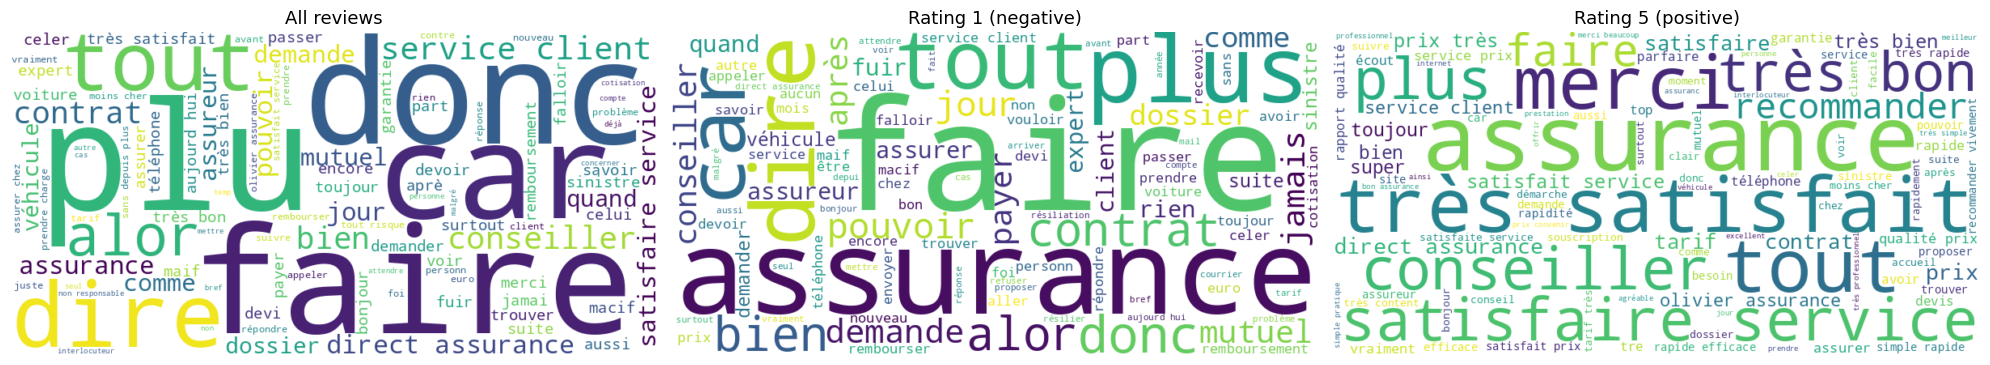

In [14]:
fig = make_subplots(rows=1, cols=2, subplot_titles=['Rating 1 (negative)', 'Rating 5 (positive)'], horizontal_spacing=0.15)
for col, note, couleurs in [(1, 1, 'Reds_r'), (2, 5, 'Blues_r')]:
    mots_note = [mot for tokens in df[df['note'] == note]['tokens_lemma'] for mot in tokens]
    top = Counter(mots_note).most_common(20)
    labels, vals = zip(*top)
    colors = getattr(px.colors.sequential, couleurs)[:len(labels)]
    fig.add_trace(go.Bar(x=list(vals), y=list(labels), orientation='h', marker_color=colors, name=f'Note {note}'), row=1, col=col)
fig.update_layout(height=600, width=1200, showlegend=False, title_text='Most Frequent Words by Rating')
fig.update_yaxes(autorange='reversed')
fig.show()

# WordClouds
fig_wc, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, subset, titre in zip(axes, [df, df[df['note']==1], df[df['note']==5]], ['All reviews', 'Rating 1 (negative)', 'Rating 5 (positive)']):
    texte = ' '.join([mot for tokens in subset['tokens_lemma'] for mot in tokens])
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100).generate(texte)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(titre, fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.show()

## A.9 - Save Cleaned Data

In [15]:
colonnes_a_supprimer = ['avis_en', 'avis_cor', 'avis_cor_en']
df = df.drop(columns=[c for c in colonnes_a_supprimer if c in df.columns])
df['tokens_str'] = df['tokens'].apply(lambda x: '|'.join(x) if isinstance(x, list) else str(x))
df['tokens_lemma_str'] = df['tokens_lemma'].apply(lambda x: '|'.join(x) if isinstance(x, list) else str(x))
df.to_csv('df_clean.csv', index=False, encoding='utf-8-sig')
print(f"df_clean.csv saved — {df.shape[0]} lignes, {df.shape[1]} colonnes")

df_clean.csv saved — 34415 lignes, 16 colonnes


---
# B - Summary, Translation and Generation

Cette partie couvre la traduction des avis du francais vers l'anglais avec le modele MarianMT (Helsinki-NLP),
puis la generation de resumes par assureur et par avis individuel avec le modele T5-small.
La traduction est necessaire car certains modeles NLP performent mieux en anglais.

## B.1 - Translation FR to EN (MarianMT)

Traduction d'un echantillon de 2000 avis avec le modele pre-entraine Helsinki-NLP/opus-mt-fr-en.

In [16]:
from transformers import MarianMTModel, MarianTokenizer
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")

print("Loading translation model FR->EN...")
model_name = 'Helsinki-NLP/opus-mt-fr-en'
tokenizer_trad = MarianTokenizer.from_pretrained(model_name)
model_trad = MarianMTModel.from_pretrained(model_name).to(device)

def traduire_batch(textes, batch_size=32):
    traductions = []
    for i in range(0, len(textes), batch_size):
        batch = textes[i:i+batch_size]
        batch = [str(t) if pd.notna(t) and str(t).strip() != "" else "empty" for t in batch]
        inputs = tokenizer_trad(batch, return_tensors='pt', padding=True, truncation=True, max_length=256).to(device)
        with torch.no_grad():
            translated = model_trad.generate(**inputs)
        results = tokenizer_trad.batch_decode(translated, skip_special_tokens=True)
        traductions.extend(results)
        print(f"  {min(i+batch_size, len(textes))}/{len(textes)} translated...")
    return traductions

SAMPLE_TRAD = 2000
print(f"Translation on sample of {SAMPLE_TRAD} reviews...")
sample_idx_trad = df.sample(n=SAMPLE_TRAD, random_state=42).index
textes_fr = df.loc[sample_idx_trad, 'avis_clean'].tolist()
resultats_trad = traduire_batch(textes_fr)

df['avis_en'] = ""
df.loc[sample_idx_trad, 'avis_en'] = resultats_trad
print(f"\nTranslation complete — {SAMPLE_TRAD} reviews translated")
for i in list(sample_idx_trad[:3]):
    print(f"\nFR : {df['avis_clean'].iloc[i][:100]}")
    print(f"EN : {df['avis_en'].iloc[i][:100]}")

Device : cuda
Loading translation model FR->EN...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translation on sample of 2000 reviews...
  32/2000 translated...
  64/2000 translated...
  96/2000 translated...
  128/2000 translated...
  160/2000 translated...
  192/2000 translated...
  224/2000 translated...
  256/2000 translated...
  288/2000 translated...
  320/2000 translated...
  352/2000 translated...
  384/2000 translated...
  416/2000 translated...
  448/2000 translated...
  480/2000 translated...
  512/2000 translated...
  544/2000 translated...
  576/2000 translated...
  608/2000 translated...
  640/2000 translated...
  672/2000 translated...
  704/2000 translated...
  736/2000 translated...
  768/2000 translated...
  800/2000 translated...
  832/2000 translated...
  864/2000 translated...
  896/2000 translated...
  928/2000 translated...
  960/2000 translated...
  992/2000 translated...
  1024/2000 translated...
  1056/2000 translated...
  1088/2000 translated...
  1120/2000 translated...
  1152/2000 translated...
  1184/2000 translated...
  1216/2000 translated...
  124

## B.2 - Summarization by Insurer (T5-small)

Pour chaque assureur, on concatene jusqu'a 50 avis traduits en anglais et on genere un resume global avec T5-small.
Les parametres no_repeat_ngram_size=3 et num_beams=4 evitent les repetitions dans les resumes.

In [17]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Loading summarization model (T5-small)...")
model_resume = AutoModelForSeq2SeqLM.from_pretrained("t5-small").to(device)
tokenizer_resume = AutoTokenizer.from_pretrained("t5-small")

def resumer_texte(texte, max_length=120, min_length=30):
    inputs = tokenizer_resume(f"summarize: {texte}", return_tensors="pt", truncation=True, max_length=1024).to(device)
    with torch.no_grad():
        output = model_resume.generate(**inputs, max_length=max_length, min_length=min_length,
                                        no_repeat_ngram_size=3, num_beams=4, early_stopping=True)
    return tokenizer_resume.decode(output[0], skip_special_tokens=True)

print("Generating summaries per insurer...\n")
resumes_assureur = {}
for assureur in df['assureur'].unique():
    avis_assureur = df[df['assureur'] == assureur]['avis_en'].dropna()
    avis_assureur = avis_assureur[avis_assureur.str.strip() != ""].tolist()
    if len(avis_assureur) == 0:
        resumes_assureur[assureur] = "No reviews available"
        continue
    if len(avis_assureur) > 50:
        avis_assureur = pd.Series(avis_assureur).sample(n=50, random_state=42).tolist()
    texte_concat = ' '.join(avis_assureur)[:2000]
    try:
        resume = resumer_texte(texte_concat)
        resumes_assureur[assureur] = resume
        print(f"--- {assureur} ---")
        print(resume[:150])
        print()
    except Exception as e:
        resumes_assureur[assureur] = "Summary not available"

df_resumes = pd.DataFrame(list(resumes_assureur.items()), columns=['assureur', 'resume_en'])
df_resumes.to_csv('resumes_assureur.csv', index=False, encoding='utf-8-sig')
print(f"\nSummaries saved — {len(df_resumes)} insurers")

Loading summarization model (T5-small)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Generating summaries per insurer...

--- Direct Assurance ---
I am satisfied with the services fast enough to complete the file which in my opinion is simple to fill the prices are attractive compared to what I p

--- L'olivier Assurance ---
olive insurance is a good welcome to all my relatives but remains a little expensive staff super nice on the phone thanks for the services that offer 

--- Matmut ---
years has the asset and for what hello frankly do not assure you at asset no service his fact years that I am at home no problem with my car zero home

--- Néoliane Santé ---
kine c is by far the worst mutual that I know I find nothing positive very bad mutual to escape absolutely always a problem to get reimbursed I have j

--- APRIL ---
new customer satisfied with the price and the services I will not give any more reviews because I am new customer at you I hope everything will go wel

--- SantéVet ---
dogs insured for several years argentian dope of years and a whippet of years. ot

## B.3 - Individual Review Summarization (sample)

In [18]:
print("Individual summarization on 500 reviews...")
SAMPLE_RESUME = 500
sample_idx_resume = df[df['avis_en'].str.strip() != ""].sample(n=SAMPLE_RESUME, random_state=42).index
df['resume_avis'] = ""
textes_en = df.loc[sample_idx_resume, 'avis_en'].tolist()
resumes = []
for i, texte in enumerate(textes_en):
    try:
        resumes.append(texte if len(texte.strip()) < 20 else resumer_texte(texte, max_length=50, min_length=10))
    except:
        resumes.append("N/A")
    if (i+1) % 100 == 0: print(f"  {i+1}/{len(textes_en)}...")
df.loc[sample_idx_resume, 'resume_avis'] = resumes
print(f"\nDone — {sum(1 for r in resumes if r != 'N/A')}/{SAMPLE_RESUME} summaries generated")

Individual summarization on 500 reviews...
  100/500...
  200/500...
  300/500...
  400/500...
  500/500...

Done — 500/500 summaries generated


## B.4 - Save

In [19]:
df.to_csv('df_complet.csv', index=False, encoding='utf-8-sig')
print(f"df_complet.csv saved — {df.shape[0]} rows, {df.shape[1]} columns")

df_complet.csv saved — 34415 rows, 18 columns


---
# C - Topic Modeling

Decouverte automatique des themes/sujets presents dans les avis avec deux approches :
- **LDA** (Latent Dirichlet Allocation) : approche classique basee sur les co-occurrences de mots
- **BERTopic** : approche moderne utilisant des sentence embeddings pour capturer le sens semantique

LDA est plus interpretable, BERTopic donne des clusters plus coherents.

## C.1 - Data Preparation for Topic Modeling

In [20]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from bertopic import BERTopic

if 'tokens_lemma_str' in df.columns and not isinstance(df['tokens_lemma'].iloc[0], list):
    df['tokens_lemma'] = df['tokens_lemma_str'].apply(lambda x: str(x).split('|') if pd.notna(x) else [])

df_topics = df[df['tokens_lemma'].apply(len) > 3].copy()
print(f"{len(df_topics)} reviews for topic modeling")

34120 reviews for topic modeling


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



## C.2 - LDA (Latent Dirichlet Allocation)

Construction d'un dictionnaire et d'un corpus bag-of-words, puis entrainement du modele LDA avec 7 topics.
Les mots trop rares (< 10 occurrences) ou trop frequents (> 50% des documents) sont filtres.

In [22]:
import warnings
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)


textes = df_topics['tokens_lemma'].tolist()
dictionnaire = corpora.Dictionary(textes)
dictionnaire.filter_extremes(no_below=10, no_above=0.5)
corpus = [dictionnaire.doc2bow(texte) for texte in textes]
print(f"Dictionary : {len(dictionnaire)} unique words | Corpus : {len(corpus)} documents")

NUM_TOPICS = 7
lda_model = LdaModel(corpus=corpus, id2word=dictionnaire, num_topics=NUM_TOPICS,
                      random_state=42, passes=10, alpha='auto', per_word_topics=True)

print(f"\nLDA — {NUM_TOPICS} Topics")
print("=" * 60)
for idx, topic in lda_model.print_topics(-1, num_words=10):
    mots = [mot.split('"')[1] for mot in topic.split('+')]
    print(f"\nTopic {idx} : {', '.join(mots)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Dictionary : 5039 unique words | Corpus : 34120 documents

LDA — 7 Topics

Topic 0 : très, service, prix, bon, assurance, rapide, satisfait, bien, merci, satisfaire

Topic 1 : assurance, chez, plus, contrat, assurer, année, cher, euro, autre, moins

Topic 2 : véhicule, sinistre, accident, assurance, responsable, assurer, non, voiture, tout, chez

Topic 3 : contrat, mois, envoyer, aucun, demande, mail, recevoir, réponse, dossier, faire

Topic 4 : mutuel, remboursement, rembourser, chien, mois, remboursemer, charge, depuis, frais, maladie

Topic 5 : faire, tout, dire, rien, bien, plus, prendre, assurance, car, pouvoir

Topic 6 : sinistre, expert, maif, dégât, après, suite, macif, charge, aucun, depuis


## C.3 - LDA Visualization (pyLDAvis)

In [23]:
vis_data = gensimvis.prepare(lda_model, corpus, dictionnaire)
pyLDAvis.display(vis_data)

## C.4 - Topic Assignment

Attribution manuelle de noms aux topics en fonction des mots-cles identifies,
puis assignation du topic dominant a chaque avis.

In [24]:
# Topic names - A ADAPTER selon vos resultats LDA
topic_names = {
    0: "Service Client", 1: "Prix / Tarifs", 2: "Remboursement / Sinistre",
    3: "Contrat / Résiliation", 4: "Couverture / Garanties",
    5: "Gestion en ligne / Site web", 6: "Satisfaction générale"
}

def get_topic_dominant(bow, model):
    topics = model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

df_topics['topic_id'] = [get_topic_dominant(bow, lda_model) for bow in corpus]
df_topics['topic_name'] = df_topics['topic_id'].map(topic_names)

print("Topic Distribution :")
print(df_topics['topic_name'].value_counts())

fig = px.histogram(df_topics, x='topic_name', color='topic_name', title='Topic Distribution (LDA)')
fig.update_layout(showlegend=False, xaxis_tickangle=-45)
fig.show()

Topic Distribution :
topic_name
Service Client                 13516
Contrat / Résiliation           7557
Prix / Tarifs                   4949
Gestion en ligne / Site web     4165
Remboursement / Sinistre        2179
Satisfaction générale           1116
Couverture / Garanties           638
Name: count, dtype: int64


## C.5 - BERTopic (Modern Approach)

BERTopic utilise des sentence embeddings (BERT) pour regrouper les avis par similarite semantique.
Contrairement a LDA qui se base sur les mots, BERTopic comprend le sens des phrases.

In [25]:
print("Training BERTopic...")
textes_bruts = df_topics['avis_clean'].tolist()
topic_model_bert = BERTopic(language="french", nr_topics=10, verbose=True)
topics_bert, probs_bert = topic_model_bert.fit_transform(textes_bruts)
df_topics['bertopic_id'] = topics_bert
display(topic_model_bert.get_topic_info().head(10))

Training BERTopic...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1067 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,18975,-1_de_et_je_le,"[de, et, je, le, la, un, pour, pas, les, en]",[tarif attractif pour les nouveaux clients je ...
1,0,6904,0_de_la_le_et,"[de, la, le, et, un, je, en, que, pas, pour]",[tout nos contrats hors mutuelle sont chez axa...
2,1,4050,1_assurance_je_prix_et,"[assurance, je, prix, et, de, suis, très, sati...",[je suis satisfait au service je veux assurer ...
3,2,3734,2_très_et_je_suis,"[très, et, je, suis, satisfait, prix, de, serv...",[je suis satisfait du service les prix me conv...
4,3,325,3_vous_pas_de_étoile,"[vous, pas, de, étoile, ne, est, je, pour, et,...",[je ne met que étoile car ce n est je ne met q...
5,4,45,4_mgen_scolaire_la_de,"[mgen, scolaire, la, de, les, enseignants, est...",[chers collègues enseignants surtout ne choisi...
6,5,31,5_tres_bon_quantant_merci,"[tres, bon, quantant, merci, bien, et, etre, k...",[je suis tres quantant etre assure chez vous m...
7,6,25,6_lait_vaches_des_pour,"[lait, vaches, des, pour, de, vache, santé, la...",[assurée à la maif depuis bientôt ans pour l h...
8,7,17,7_français_des_qui_pas,"[français, des, qui, pas, ce, parlent, ne, de,...",[le service client est incompétent et ne parle...
9,8,14,8_internaute_supprimée_intervention_demande,"[internaute, supprimée, intervention, demande,...",[intervention supprimée à la demande de l inte...


In [26]:
# BERTopic Visualizations
fig_topics = topic_model_bert.visualize_topics()
fig_topics.show()
fig_barchart = topic_model_bert.visualize_barchart(top_n_topics=8)
fig_barchart.show()

## C.6 - Save Topics

In [27]:
df['topic_lda'] = ""
df.loc[df_topics.index, 'topic_lda'] = df_topics['topic_name']
df.to_csv('df_complet.csv', index=False, encoding='utf-8-sig')
print("Topics saved to df_complet.csv")

Topics saved to df_complet.csv


---
# D - Word Embeddings (Word2Vec)

Entrainement d'un modele Word2Vec Skip-Gram sur le corpus lemmatise pour apprendre des representations vectorielles des mots.
Ces embeddings capturent les relations semantiques : les mots ayant des sens proches ont des vecteurs proches.
Visualisation avec t-SNE et export pour TensorBoard Embedding Projector.

In [ ]:
df = pd.read_csv('df_complet.csv')
print(f"{df.shape[0]} lignes chargees")

## D.1 - Word2Vec Training

In [ ]:
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

df = pd.read_csv('df_complet.csv')
if 'tokens_lemma_str' in df.columns:
    df['tokens_lemma'] = df['tokens_lemma_str'].apply(lambda x: str(x).split('|') if pd.notna(x) else [])

sentences = [tokens for tokens in df['tokens_lemma'] if len(tokens) > 2]
print(f"{len(sentences)} sentences for Word2Vec")

print("Training Word2Vec (Skip-Gram)...")
w2v_model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=5,
                      workers=4, sg=1, epochs=20, seed=42)
print(f"Vocabulary size : {len(w2v_model.wv)} words")

for mot in ['assurance', 'prix', 'remboursement', 'sinistre', 'service']:
    try:
        similaires = w2v_model.wv.most_similar(mot, topn=5)
        print(f"\n{mot} -> {[m for m, _ in similaires]}")
    except KeyError:
        print(f"\n{mot} -> not in vocabulary")

34238 sentences for Word2Vec
Training Word2Vec (Skip-Gram)...
Vocabulary size : 7653 words

assurance -> ['assuranc', 'asuurance', 'souscrivez', 'assureur', 'asssurance']

prix -> ['tarif', 'couteus', 'concurrenc', 'proposees', 'convienn']

remboursement -> ['remboursemer', 'lentille', 'dentaire', 'rembourser', 'rac']

sinistre -> ['incident', 'accident', 'eal', 'responsable', 'déclarer']

service -> ['qualité', 'téléopérateur', 'recommenderai', 'séraphin', 'comunication']


## D.2 - Embedding Visualization (t-SNE)

Projection des vecteurs de mots en 2D avec t-SNE pour visualiser les clusters semantiques.

In [ ]:
mots_visualises = ['assurance', 'remboursement', 'prix', 'contrat', 'service',
    'sinistre', 'garantie', 'résiliation', 'devis', 'client',
    'rapide', 'cher', 'bien', 'mauvais', 'excellent']
mots_existants = [m for m in mots_visualises if m in w2v_model.wv]
vecteurs = np.array([w2v_model.wv[m] for m in mots_existants])

tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(mots_existants)-1))
coords = tsne.fit_transform(vecteurs)

fig = px.scatter(x=coords[:, 0], y=coords[:, 1], text=mots_existants,
                 title='t-SNE Visualization of Word2Vec Embeddings')
fig.update_traces(textposition='top center', marker=dict(size=12, color='#2E86AB'))
fig.update_layout(height=600, width=800)
fig.show()

## D.3 - Cosine Similarity and Euclidean Distance

Implementation des metriques de similarite entre paires de mots pour valider la qualite des embeddings.

In [ ]:
from numpy.linalg import norm

def distance_euclidienne(m1, m2, model):
    v1, v2 = model.wv[m1], model.wv[m2]
    return np.sqrt(np.sum((v1 - v2) ** 2))

def similarite_cosine(m1, m2, model):
    return model.wv.similarity(m1, m2)

paires = [('prix', 'cher'), ('service', 'client'), ('bon', 'mauvais'), ('rapide', 'lent')]
print(f"{'Pair':<25} {'Cosine':>10} {'Euclidean':>12}")
print("=" * 50)
for m1, m2 in paires:
    try:
        cos = similarite_cosine(m1, m2, w2v_model)
        euc = distance_euclidienne(m1, m2, w2v_model)
        print(f"{m1+' / '+m2:<25} {cos:>10.4f} {euc:>12.4f}")
    except KeyError:
        print(f"{m1+' / '+m2:<25} {'Unknown':>10}")

Pair                          Cosine    Euclidean
prix / cher                   0.5319       2.8698
service / client              0.5154       2.3477
bon / mauvais                 0.5244       2.8018
rapide / lent                 0.4148       3.6133


## D.4 - TensorBoard Export

Export des embeddings au format TSV pour visualisation dans TensorBoard Embedding Projector (https://projector.tensorflow.org/).

In [ ]:
os.makedirs('tensorboard_logs', exist_ok=True)
vocab = list(w2v_model.wv.key_to_index.keys())[:2000]
with open('tensorboard_logs/vectors.tsv', 'w', encoding='utf-8') as fv, \
     open('tensorboard_logs/metadata.tsv', 'w', encoding='utf-8') as fm:
    for mot in vocab:
        fv.write('\t'.join(str(x) for x in w2v_model.wv[mot]) + '\n')
        fm.write(mot + '\n')
print(f"TensorBoard export : {len(vocab)} word vectors in tensorboard_logs/")

TensorBoard export : 2000 word vectors in tensorboard_logs/


---
# E - Supervised Learning (Sentiment Classification)

Construction et comparaison de plusieurs modeles de classification de sentiment, du plus simple au plus complexe :
1. TF-IDF + Classical ML (Logistic Regression, SVM, Naive Bayes, Random Forest)
2. Neural Network with trainable Embedding layer
3. CNN with pre-trained Word2Vec embeddings
4. Bidirectional LSTM
5. USE (Universal Sentence Encoder / Sentence-BERT)
6. CamemBERT (Transformer fine-tuning)

Le dataset est rééquilibré (balanced) avant l'entrainement pour eviter le biais vers la classe majoritaire.

## E.1 - Data Preparation (Balanced Dataset)

On filtre les avis neutres (note 3), on cree une variable binaire sentiment (positif >= 4, negatif <= 2),
puis on reequilibre le dataset par under-sampling de la classe majoritaire.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils import resample

df = pd.read_csv('df_complet.csv')
df_ml = df[df['note'] != 3].copy()
df_ml['sentiment'] = (df_ml['note'] >= 4).astype(int)
df_ml = df_ml.dropna(subset=['avis_clean'])

print("Before balancing :")
print(df_ml['sentiment'].value_counts())

# Under-sampling the majority class
df_pos = df_ml[df_ml['sentiment'] == 1]
df_neg = df_ml[df_ml['sentiment'] == 0]
if len(df_neg) > len(df_pos):
    df_neg = resample(df_neg, n_samples=len(df_pos), random_state=42)
else:
    df_pos = resample(df_pos, n_samples=len(df_neg), random_state=42)
df_ml = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing :")
print(df_ml['sentiment'].value_counts())

X = df_ml['avis_clean']
y = df_ml['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain : {len(X_train)} | Test : {len(X_test)}")

Before balancing :
sentiment
0    21302
1     9731
Name: count, dtype: int64

After balancing :
sentiment
0    9731
1    9731
Name: count, dtype: int64

Train : 15569 | Test : 3893


## E.2 - TF-IDF + Classical Machine Learning

Vectorisation TF-IDF (20000 features, bigrams) puis entrainement de 4 classifieurs classiques.

In [ ]:
modeles_classiques = {
    'Logistic Regression': LogisticRegression(max_iter=500, C=1.0),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=2000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}
resultats_classiques = {}
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("=" * 65)
for nom, clf in modeles_classiques.items():
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    resultats_classiques[nom] = {'accuracy': acc, 'f1': f1, 'model': clf}
    print(f"{nom:<25} {acc:>10.4f} {f1:>10.4f}")
print("=" * 65)

Model                       Accuracy   F1-Score
Logistic Regression           0.8294     0.8289
Naive Bayes                   0.8276     0.8271
Linear SVM                    0.8292     0.8291
Random Forest                 0.8479     0.8476


## E.3 - Best Classical Model - Confusion Matrix

Best model : Random Forest

              precision    recall  f1-score   support

     Négatif       0.88      0.80      0.84      1947
     Positif       0.82      0.90      0.85      1946

    accuracy                           0.85      3893
   macro avg       0.85      0.85      0.85      3893
weighted avg       0.85      0.85      0.85      3893



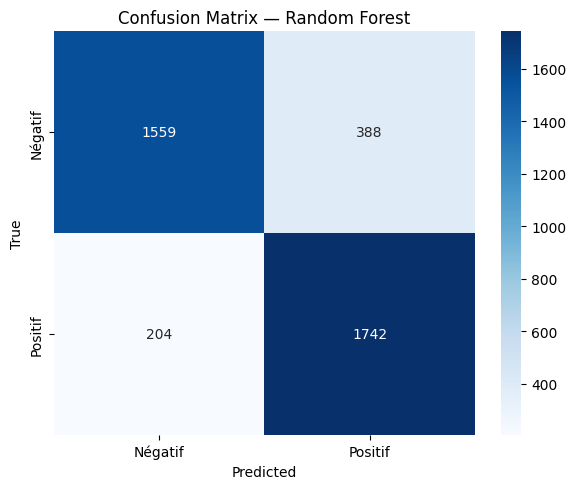

In [ ]:
meilleur_nom = max(resultats_classiques, key=lambda k: resultats_classiques[k]['f1'])
meilleur_clf = resultats_classiques[meilleur_nom]['model']
y_pred_best = meilleur_clf.predict(X_test_tfidf)

print(f"Best model : {meilleur_nom}\n")
print(classification_report(y_test, y_pred_best, target_names=['Négatif', 'Positif']))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Négatif','Positif'], yticklabels=['Négatif','Positif'])
plt.title(f'Confusion Matrix — {meilleur_nom}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## E.4 - Neural Network with Embedding Layer (Keras)

Modele sequentiel avec une couche Embedding entrainable, suivi de GlobalAveragePooling et de couches Dense.
L'early stopping evite le sur-apprentissage.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

VOCAB_SIZE, MAX_LEN, EMBED_DIM, BATCH_SIZE, EPOCHS = 20000, 150, 64, 64, 10

tokenizer_keras = KerasTokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_test), maxlen=MAX_LEN)

model_embed = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(), Dense(128, activation='relu'), Dropout(0.3),
    Dense(64, activation='relu'), Dropout(0.2), Dense(1, activation='sigmoid')
])
model_embed.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_embed = model_embed.fit(X_train_seq, y_train, validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[EarlyStopping(patience=3, restore_best_weights=True)], verbose=1)
_, acc_embed = model_embed.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nEmbedding Model — Test accuracy : {acc_embed:.4f}")

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7216 - loss: 0.5550 - val_accuracy: 0.7881 - val_loss: 0.4733
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4396 - val_accuracy: 0.8311 - val_loss: 0.4048
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8224 - loss: 0.4062 - val_accuracy: 0.8298 - val_loss: 0.3987
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8423 - loss: 0.3743 - val_accuracy: 0.8330 - val_loss: 0.3925
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8481 - loss: 0.3611 - val_accuracy: 0.8208 - val_loss: 0.4236
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8536 - loss: 0.3529 - val_accuracy: 0.8099 - val_loss: 0.4205
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8451 - loss: 0.3606 - val_accuracy: 0.8356 - val_loss: 0.4006

Embedding Model — Test accuracy : 0.8320


## E.5 - Training Curves

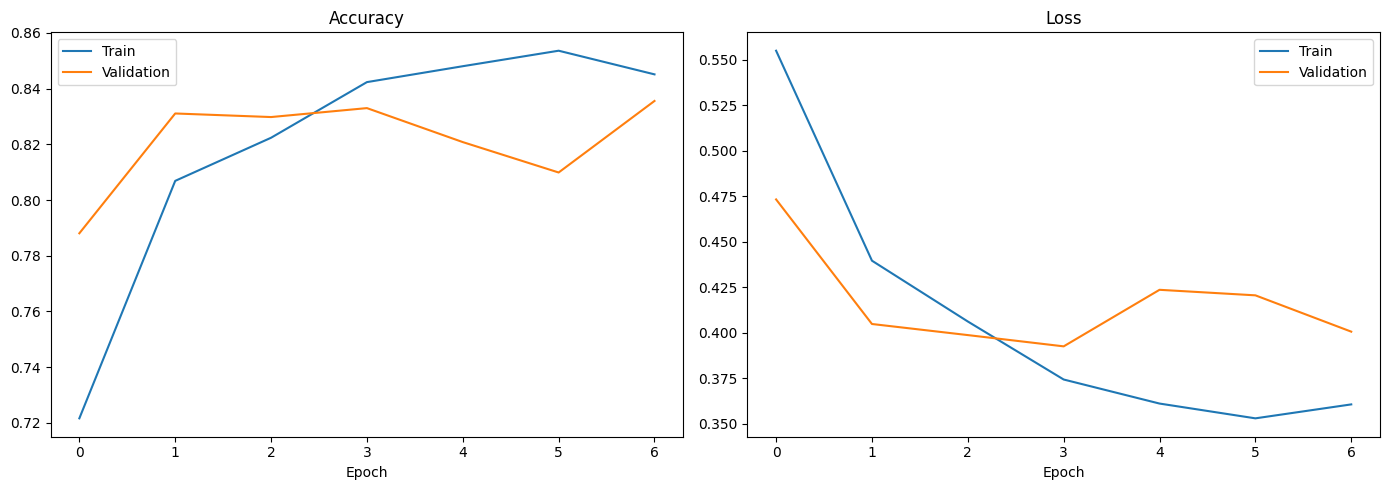

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_embed.history['accuracy'], label='Train')
axes[0].plot(history_embed.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(history_embed.history['loss'], label='Train')
axes[1].plot(history_embed.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## E.6 - TensorBoard Export (Keras Embeddings)

In [ ]:
os.makedirs('tensorboard_keras', exist_ok=True)
weights = model_embed.get_layer('embedding').get_weights()[0]
vocab_keras = tokenizer_keras.index_word
with io.open('tensorboard_keras/vectors.tsv', 'w', encoding='utf-8') as fv, \
     io.open('tensorboard_keras/metadata.tsv', 'w', encoding='utf-8') as fm:
    for idx in range(1, min(VOCAB_SIZE, len(vocab_keras)+1)):
        mot = vocab_keras.get(idx, f'UNK_{idx}')
        fv.write('\t'.join(str(x) for x in weights[idx]) + '\n')
        fm.write(mot + '\n')
print("Keras embeddings exported for TensorBoard")

Keras embeddings exported for TensorBoard


## E.7 - CNN with Pre-trained Word2Vec Embeddings

Le CNN utilise les poids Word2Vec comme embedding initial (non-trainable), ce qui permet de transferer
les connaissances semantiques apprises lors de l'entrainement Word2Vec.

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

embedding_matrix = np.zeros((VOCAB_SIZE, 100))
for mot, idx in tokenizer_keras.word_index.items():
    if idx < VOCAB_SIZE and mot in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[mot]

model_pretrained = Sequential([
    Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    Conv1D(128, 5, activation='relu'), MaxPooling1D(pool_size=2),
    Conv1D(64, 5, activation='relu'), GlobalAveragePooling1D(),
    Dense(64, activation='relu'), Dropout(0.3), Dense(1, activation='sigmoid')
])
model_pretrained.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_pretrained = model_pretrained.fit(X_train_seq, y_train, validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[EarlyStopping(patience=3, restore_best_weights=True)], verbose=1)
_, acc_pretrained = model_pretrained.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nCNN + Word2Vec — Test accuracy : {acc_pretrained:.4f}")

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7929 - loss: 0.4592 - val_accuracy: 0.8240 - val_loss: 0.4248
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8264 - loss: 0.4159 - val_accuracy: 0.8215 - val_loss: 0.4210
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8323 - loss: 0.4013 - val_accuracy: 0.8259 - val_loss: 0.4091
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8379 - loss: 0.3895 - val_accuracy: 0.8272 - val_loss: 0.4004
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8474 - loss: 0.3741 - val_accuracy: 0.8311 - val_loss: 0.4097
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8541 - loss: 0.3594 - val_accuracy: 0.8227 - val_loss: 0.4061
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8573 - loss: 0.3487 - val_accuracy: 0.8240 - val_loss: 0.3994
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8708 - loss: 0.3187 - val_accuracy: 

## E.8 - Bidirectional LSTM

Architecture LSTM bidirectionnelle qui lit la sequence dans les deux sens pour capturer
le contexte complet de chaque mot.

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional

model_lstm = Sequential([
    Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix], input_length=MAX_LEN, trainable=True),
    Bidirectional(LSTM(64, return_sequences=False, dropout=0.2)),
    Dense(64, activation='relu'), Dropout(0.3), Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train_seq, y_train, validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[EarlyStopping(patience=3, restore_best_weights=True)], verbose=1)
_, acc_lstm = model_lstm.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nBi-LSTM — Test accuracy : {acc_lstm:.4f}")

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7957 - loss: 0.4571 - val_accuracy: 0.8356 - val_loss: 0.4004
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8426 - loss: 0.3833 - val_accuracy: 0.8369 - val_loss: 0.3979
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8573 - loss: 0.3523 - val_accuracy: 0.8324 - val_loss: 0.4025
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8705 - loss: 0.3202 - val_accuracy: 0.8401 - val_loss: 0.3999
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8845 - loss: 0.2842 - val_accuracy: 0.8234 - val_loss: 0.4342

Bi-LSTM — Test accuracy : 0.8389


### Memory cleanup avant les modeles Transformer

In [ ]:
import torch
import gc
import tensorflow as tf

# Supprimer les modeles Keras s'ils existent encore
for m in ['model_embed', 'model_pretrained', 'model_lstm']:
    if m in dir():
        exec(f'del {m}')

gc.collect()
tf.keras.backend.clear_session()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("Memory freed")

Memory freed


## E.9 - USE / Sentence-BERT

Le modele paraphrase-multilingual-MiniLM-L12-v2 encode chaque avis en un vecteur de 384 dimensions
qui capture le sens global de la phrase. On utilise ensuite une Logistic Regression sur ces embeddings.

In [ ]:
from sentence_transformers import SentenceTransformer

print("Loading Sentence-BERT model...")
use_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Encoding sentences...")
X_train_use = use_model.encode(X_train.tolist(), batch_size=64, show_progress_bar=True)
X_test_use = use_model.encode(X_test.tolist(), batch_size=64, show_progress_bar=True)

clf_use = LogisticRegression(max_iter=1000, C=1.0)
clf_use.fit(X_train_use, y_train)
y_pred_use = clf_use.predict(X_test_use)
acc_use = accuracy_score(y_test, y_pred_use)
f1_use = f1_score(y_test, y_pred_use, average='weighted')
print(f"\nUSE + LR — Accuracy : {acc_use:.4f} | F1 : {f1_use:.4f}")
print(classification_report(y_test, y_pred_use, target_names=['Négatif', 'Positif']))

# Free memory
del use_model, X_train_use, X_test_use
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("USE memory freed")

Loading Sentence-BERT model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding sentences...


Batches:   0%|          | 0/244 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]


USE + LR — Accuracy : 0.8235 | F1 : 0.8228
              precision    recall  f1-score   support

     Négatif       0.87      0.76      0.81      1947
     Positif       0.79      0.89      0.83      1946

    accuracy                           0.82      3893
   macro avg       0.83      0.82      0.82      3893
weighted avg       0.83      0.82      0.82      3893

USE memory freed


## E.10 - CamemBERT Fine-tuning

Fine-tuning du modele CamemBERT (BERT pre-entraine sur du francais) pour la classification de sentiment.
Parametres reduits (batch_size=8, MAX_LEN=64, N=3000) pour eviter les problemes de memoire.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

MODEL_NAME = 'camembert-base'
MAX_LEN_BERT = 64

class AvisDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_len)
        self.labels = list(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

N = 3000
X_tr_s, y_tr_s = X_train[:N], y_train[:N]
X_te_s, y_te_s = X_test[:500], y_test[:500]
train_dataset = AvisDataset(X_tr_s, y_tr_s.values, bert_tokenizer, MAX_LEN_BERT)
eval_dataset = AvisDataset(X_te_s, y_te_s.values, bert_tokenizer, MAX_LEN_BERT)

training_args = TrainingArguments(
    output_dir='./camembert_results', num_train_epochs=2, eval_strategy='epoch',
    per_device_train_batch_size=8, per_device_eval_batch_size=16,
    learning_rate=2e-5, warmup_steps=50, weight_decay=0.01,
    save_strategy='epoch', load_best_model_at_end=True,
    logging_dir='./logs', logging_steps=50, report_to='none', fp16=True
)

trainer = Trainer(model=bert_model, args=training_args, train_dataset=train_dataset, eval_dataset=eval_dataset)
print("Fine-tuning CamemBERT...")
trainer.train()

preds_bert = trainer.predict(eval_dataset)
y_pred_bert = np.argmax(preds_bert.predictions, axis=1)
acc_bert = accuracy_score(y_te_s, y_pred_bert)
print(f"\nCamemBERT — Accuracy : {acc_bert:.4f}")
print(classification_report(y_te_s, y_pred_bert, target_names=['Négatif', 'Positif']))

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,0.462829,0.423557
2,0.328037,0.420583


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


CamemBERT — Accuracy : 0.8340
              precision    recall  f1-score   support

     Négatif       0.94      0.71      0.81       249
     Positif       0.77      0.95      0.85       251

    accuracy                           0.83       500
   macro avg       0.85      0.83      0.83       500
weighted avg       0.85      0.83      0.83       500



In [ ]:
import gc
import torch

# Liberer CamemBERT de la memoire GPU
if 'bert_model' in dir():
    del bert_model
if 'trainer' in dir():
    del trainer
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed")

GPU memory freed


## E.11 - Model Comparison

Tableau comparatif de tous les modeles entraines, tries par accuracy decroissante.

In [ ]:
resultats_finaux = {
    'LR + TF-IDF': resultats_classiques['Logistic Regression']['accuracy'],
    'NB + TF-IDF': resultats_classiques['Naive Bayes']['accuracy'],
    'SVM + TF-IDF': resultats_classiques['Linear SVM']['accuracy'],
    'RF + TF-IDF': resultats_classiques['Random Forest']['accuracy'],
    'Embedding (Keras)': acc_embed,
    'CNN + Word2Vec': acc_pretrained,
    'Bi-LSTM + Word2Vec': acc_lstm,
    'USE + LR': acc_use,
    'CamemBERT': acc_bert,
}
df_res = pd.DataFrame(list(resultats_finaux.items()), columns=['Model', 'Accuracy'])
df_res = df_res.sort_values('Accuracy', ascending=True)

fig = px.bar(df_res, x='Accuracy', y='Model', orientation='h',
             title='Model Comparison — Sentiment Classification',
             color='Accuracy', color_continuous_scale='Blues',
             text=df_res['Accuracy'].apply(lambda x: f'{x:.3f}'))
fig.update_layout(height=500, xaxis_range=[0.5, 1.0])
fig.update_traces(textposition='outside')
fig.show()

## E-12 Star Rating Prediction (5 classes)

Star Prediction — Accuracy : 0.5336 | MAE : 0.61
              precision    recall  f1-score   support

           1       0.60      0.87      0.71      1452
           2       0.36      0.16      0.22       743
           3       0.35      0.16      0.22       676
           4       0.46      0.51      0.49       977
           5       0.58      0.59      0.58       970

    accuracy                           0.53      4818
   macro avg       0.47      0.46      0.45      4818
weighted avg       0.50      0.53      0.50      4818



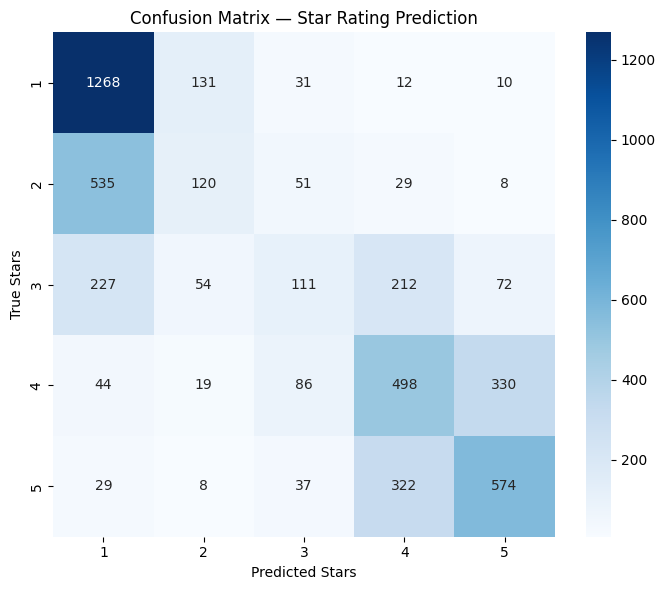

lr_stars_model.pkl saved


In [ ]:
from sklearn.metrics import mean_absolute_error

df_stars = pd.read_csv('df_complet.csv').dropna(subset=['avis_clean', 'note'])
X_stars = df_stars['avis_clean']
y_stars = df_stars['note'].astype(int)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_stars, y_stars, test_size=0.2, random_state=42, stratify=y_stars)

X_tr_tfidf_s = tfidf.transform(X_tr_s)
X_te_tfidf_s = tfidf.transform(X_te_s)

clf_stars = LogisticRegression(max_iter=500, C=1.0, multi_class='multinomial')
clf_stars.fit(X_tr_tfidf_s, y_tr_s)
y_pred_stars = clf_stars.predict(X_te_tfidf_s)

acc_stars = accuracy_score(y_te_s, y_pred_stars)
mae_stars = mean_absolute_error(y_te_s, y_pred_stars)

print(f"Star Prediction — Accuracy : {acc_stars:.4f} | MAE : {mae_stars:.2f}")
print(classification_report(y_te_s, y_pred_stars))

cm_stars = confusion_matrix(y_te_s, y_pred_stars)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_stars, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.title('Confusion Matrix — Star Rating Prediction')
plt.ylabel('True Stars'); plt.xlabel('Predicted Stars')
plt.tight_layout()
plt.show()

# Sauvegarder le modele stars
with open('lr_stars_model.pkl', 'wb') as f:
    pickle.dump(clf_stars, f)
print("lr_stars_model.pkl saved")

---
# F - Results Interpretation and Error Analysis

Analyse critique des resultats : identification des faux positifs/negatifs, detection de sentiment
sur l'ensemble du dataset, classification thematique, et zero-shot classification avec un LLM.

## F.1 - Error Analysis

Identification et analyse des avis mal classes (faux positifs et faux negatifs) pour comprendre les limites du modele.

In [ ]:
y_pred_lr = resultats_classiques['Logistic Regression']['model'].predict(X_test_tfidf)
df_errors = X_test.to_frame(name='avis')
df_errors['y_true'] = y_test.values
df_errors['y_pred'] = y_pred_lr
df_errors['erreur'] = df_errors['y_true'] != df_errors['y_pred']

faux_positifs = df_errors[(df_errors['y_true'] == 0) & (df_errors['y_pred'] == 1)]
faux_negatifs = df_errors[(df_errors['y_true'] == 1) & (df_errors['y_pred'] == 0)]

print(f"False Positives : {len(faux_positifs)} | False Negatives : {len(faux_negatifs)}")
print(f"Error rate : {df_errors['erreur'].mean():.1%}")

print("\n--- False Positives (predicted positive, actually negative) ---")
for avis in faux_positifs['avis'].head(3):
    print(f"  > {avis[:120]}")

print("\n--- False Negatives (predicted negative, actually positive) ---")
for avis in faux_negatifs['avis'].head(3):
    print(f"  > {avis[:120]}")

False Positives : 439 | False Negatives : 225
Error rate : 17.1%

--- False Positives (predicted positive, actually negative) ---
  > satisfait des prix et des propositions de date de prelevement qui permette de choisir la date a laquelle nous souhaitons
  > satisfait service accueil téléphonique très bien réception des documents très bonne et très rapide correspondante téléph
  > nickel très bien expliquer et très bon prix je recommande dommage paiement annuel j espère que l année prochaine je pour

--- False Negatives (predicted negative, actually positive) ---
  > je me suis retrouvé avec un pneu crevé ce matin j ai contacté le service dépannage et minutes plus tard mon pneu était r
  > nous avons eu sinistres un dégât des eaux et un appareil ménager endommagé par la foudre et nous n avons eu aucun problè
  > j ai changé d auto et d assurance auto pour direct assurance la raison de mon choix est principalement financière assura


## F.2 - Sentiment Detection on Full Dataset

In [ ]:
df_full = pd.read_csv('df_complet.csv').dropna(subset=['avis_clean'])
X_full_tfidf = tfidf.transform(df_full['avis_clean'])
df_full['sentiment_pred'] = resultats_classiques['Logistic Regression']['model'].predict(X_full_tfidf)
df_full['sentiment_label'] = df_full['sentiment_pred'].map({1: 'Positif', 0: 'Négatif'})

pivot = df_full.groupby(['note', 'sentiment_label']).size().reset_index(name='count')
fig = px.bar(pivot, x='note', y='count', color='sentiment_label', barmode='group',
             title='Predicted Sentiment vs Actual Rating')
fig.show()

sent_by_assureur = df_full.groupby('assureur')['sentiment_pred'].mean().sort_values()
fig2 = px.bar(x=sent_by_assureur.values, y=sent_by_assureur.index, orientation='h',
              title='Average Sentiment Score by Insurer', labels={'x': 'Positive ratio', 'y': 'Insurer'})
fig2.show()

## F.3 - Topic Classification with Classical ML

Topic Classification Report :
                             precision    recall  f1-score   support

      Contrat / Résiliation       0.86      0.50      0.63       313
     Couverture / Garanties       0.90      0.97      0.94      2642
Gestion en ligne / Site web       0.81      0.86      0.83      1410
              Prix / Tarifs       0.77      0.83      0.80      1488
   Remboursement / Sinistre       0.86      0.08      0.15        74
      Satisfaction générale       0.85      0.46      0.60       244
             Service Client       0.85      0.71      0.78       653

                   accuracy                           0.84      6824
                  macro avg       0.84      0.63      0.67      6824
               weighted avg       0.84      0.84      0.83      6824



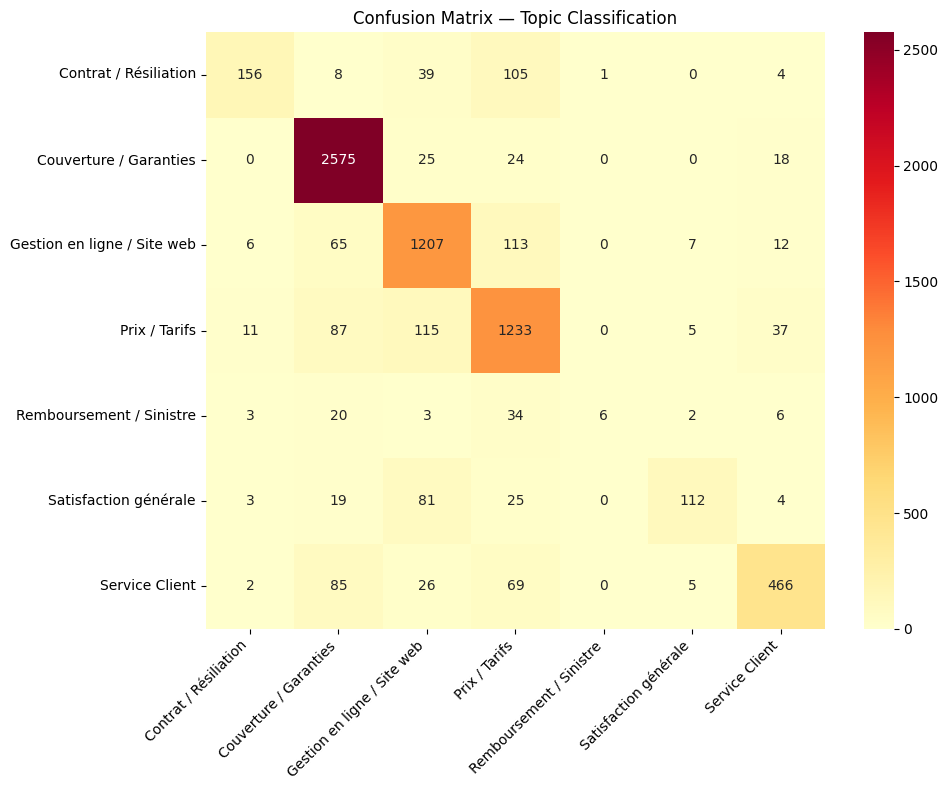

In [ ]:
df_topics_ml = df_full.dropna(subset=['topic_lda'])
df_topics_ml = df_topics_ml[df_topics_ml['topic_lda'] != '']
X_topic = df_topics_ml['avis_clean']
y_topic = df_topics_ml['topic_lda']

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_topic, y_topic, test_size=0.2, random_state=42, stratify=y_topic)
X_tr_t_tfidf = tfidf.transform(X_tr_t)
X_te_t_tfidf = tfidf.transform(X_te_t)

clf_topic = LogisticRegression(max_iter=500, C=1.0, multi_class='auto')
clf_topic.fit(X_tr_t_tfidf, y_tr_t)
y_pred_topic = clf_topic.predict(X_te_t_tfidf)

print("Topic Classification Report :")
print(classification_report(y_te_t, y_pred_topic))

topics_uniq = sorted(y_topic.unique())
cm_t = confusion_matrix(y_te_t, y_pred_topic, labels=topics_uniq)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_t, annot=True, fmt='d', cmap='YlOrRd', xticklabels=topics_uniq, yticklabels=topics_uniq)
plt.title('Confusion Matrix — Topic Classification')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## F.4 - Zero-Shot Classification (LLM)

Utilisation du modele XLM-RoBERTa (fine-tune sur XNLI) pour classifier les avis sans entrainement prealable.
Le modele recoit les labels candidats et predit le plus probable pour chaque avis.

In [ ]:
gc.collect()
torch.cuda.empty_cache()

from transformers import pipeline as hf_pipeline

# Forcer sur CPU car le modele est trop gros pour le GPU
classifier_zeroshot = hf_pipeline('zero-shot-classification', model='joeddav/xlm-roberta-large-xnli', device=-1)
labels = ['prix', 'service client', 'remboursement', 'contrat', 'couverture']

exemples = df_full['avis_clean'].dropna().sample(5, random_state=42).tolist()
print("Zero-Shot Classification Examples :")
print("=" * 60)
for avis in exemples:
    result = classifier_zeroshot(avis[:300], candidate_labels=labels)
    print(f"\nReview : {avis[:80]}...")
    print(f"  -> Predicted topic : {result['labels'][0]} ({result['scores'][0]:.2f})")

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Zero-Shot Classification Examples :

Review : a éviter absolument le service client inexistant est un désastre et extrêmement ...
  -> Predicted topic : service client (0.83)

Review : bonjour mon mari est en and depuis le avril nous avons envoyé les documents par ...
  -> Predicted topic : service client (0.55)

Review : ne prenez pas harmonie mutuelle une fois le contrat signé nous avons que des enn...
  -> Predicted topic : contrat (0.56)

Review : la misère...
  -> Predicted topic : couverture (0.45)

Review : j ai eu une réponse à mon devis rapidement et je suis satisfait de se que l ont ...
  -> Predicted topic : prix (0.46)


## F.5 - Limitations and Future Improvements

**Limites identifiees :**
- Le dataset original contenait plus d'avis negatifs que positifs, creant un biais corrige par under-sampling
- Le topic modeling LDA produit parfois des topics trop generiques ("Couverture / Garanties" est un fourre-tout)
- Les resumes T5-small sont parfois repetitifs car les avis individuels sont courts
- La correction orthographique a ete limitee a un echantillon de 2000 avis pour des raisons de temps

**Pistes d'amelioration :**
- Utiliser SMOTE ou class weights pour un reequilibrage plus sophistique
- Remplacer LDA par le zero-shot classifier pour la detection de themes en production
- Utiliser un modele de resume plus puissant (BART-large, T5-base)
- Ajouter une classe neutre (note 3) pour un systeme 3 classes
- Augmenter la taille des donnees d'entrainement pour CamemBERT

---
# G - Model Export and Streamlit Application

Sauvegarde des modeles entraines (TF-IDF vectorizer, Logistic Regression sentiment, Logistic Regression topics)
au format pickle, puis creation de l'application web interactive AssurVision avec Streamlit.

## G.1 - Save Models and Data

In [ ]:
df_full.to_csv('df_final.csv', index=False, encoding='utf-8-sig')
print(f"df_final.csv — {df_full.shape[0]} rows")

with open('tfidf_vectorizer.pkl', 'wb') as f: pickle.dump(tfidf, f)
with open('lr_sentiment_model.pkl', 'wb') as f: pickle.dump(resultats_classiques['Logistic Regression']['model'], f)
with open('lr_topic_model.pkl', 'wb') as f: pickle.dump(clf_topic, f)
print("Models saved (.pkl)")

# Download files
from google.colab import files
for f_name in ['df_final.csv', 'tfidf_vectorizer.pkl', 'lr_sentiment_model.pkl', 'lr_topic_model.pkl', 'lr_stars_model.pkl', 'resumes_assureur.csv']:
    try:
        files.download(f_name)
        print(f"  Downloaded : {f_name}")
    except:
        print(f"  Not found : {f_name}")

df_final.csv — 34414 rows
Models saved (.pkl)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded : df_final.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded : lr_stars_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded : resumes_assureur.csv


## G.2 - Streamlit Application (AssurVision)

L'application AssurVision est une app web interactive construite avec Streamlit qui offre 6 fonctionnalites :
1. **Prediction** : prediction de sentiment et theme pour un avis saisi par l'utilisateur
2. **Resume** : resume IA et metriques par assureur
3. **Explication** : visualisation des mots influents (feature importance)
4. **Recherche** : recherche d'avis par filtres (assureur, note, theme, mot-cle)
5. **RAG** : recherche semantique avec Sentence-BERT
6. **QA** : question-answering sur la base d'avis

Pour lancer l'application :
- **En local** : `python -m streamlit run app_insuranalytics.py`
- **Sur Colab** : utiliser ngrok pour creer un tunnel (voir cellule ci-dessous)

## G.3 - Launch Application

In [ ]:
# Verifier que les fichiers necessaires existent
import os
print("Files check :")
for f in ['app_insuranalytics.py', 'df_final.csv', 'tfidf_vectorizer.pkl', 'lr_sentiment_model.pkl', 'lr_topic_model.pkl']:
    status = "OK" if os.path.exists(f) else "MISSING"
    print(f"  [{status}] {f}")

print("\nPour lancer en local : python -m streamlit run app_insuranalytics.py")
print("Pour lancer sur Colab : decommenter et executer la cellule suivante")

Files check :
  [MISSING] app_insuranalytics.py
  [OK] df_final.csv
  [OK] tfidf_vectorizer.pkl
  [OK] lr_sentiment_model.pkl
  [OK] lr_topic_model.pkl

Pour lancer en local : python -m streamlit run app_insuranalytics.py
Pour lancer sur Colab : decommenter et executer la cellule suivante


In [ ]:
# === LANCEMENT SUR COLAB  ===
!pkill ngrok 2>/dev/null
import time; time.sleep(2)
NGROK_TOKEN = "LE TOKEN NGROK ICI"
from pyngrok import ngrok, conf
conf.get_default().auth_token = NGROK_TOKEN
import subprocess
subprocess.Popen(["streamlit", "run", "app_insuranalytics.py", "--server.port", "8501", "--server.headless", "true"])
time.sleep(8)
tunnel = ngrok.connect(8501)
print(f"AssurVision accessible ici : {tunnel.public_url}")

AssurVision accessible ici : https://wavier-wilford-carotidal.ngrok-free.dev
